### Importing libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the data

In [20]:
data = pd.read_parquet('../data/artifacts/03_train.parquet')

pd.set_option('display.max_columns', None)

data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,item_count,total_price,total_freight_value,payment_count,total_payment,avg_product_name_length,avg_product_description_length,avg_product_height_cm,avg_product_length_cm,avg_product_photos_qty,avg_product_width_cm,avg_product_weight_g,product_count,seller_count,late
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,28013,1.0,58.900002,13.290000,1.0,72.190002,58.0,598.0,9.0,28.0,4.0,14.0,650.0,1.0,1.0,0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,1.0,239.899994,19.930000,1.0,259.829987,56.0,239.0,30.0,50.0,2.0,40.0,30000.0,1.0,1.0,0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,1.0,199.000000,17.870001,1.0,216.869995,59.0,695.0,13.0,33.0,2.0,33.0,3050.0,1.0,1.0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,13226,1.0,199.899994,18.139999,1.0,218.039993,59.0,409.0,40.0,35.0,1.0,30.0,3750.0,1.0,1.0,0
5,00048cc3ae777c65dbb7d2a0634bc1ea,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:34,2017-05-17 03:55:27,2017-05-17 11:05:55,2017-05-22 13:44:35,2017-06-06,85c835d128beae5b4ce8602c491bf385,uberaba,MG,38017,1.0,21.900000,12.690000,1.0,34.590000,36.0,558.0,8.0,24.0,1.0,15.0,450.0,1.0,1.0,0


### EDA

In [21]:
data.shape

(67533, 27)

In [22]:
data.info()

<class 'pandas.DataFrame'>
Index: 67533 entries, 0 to 96474
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        67533 non-null  str           
 1   customer_id                     67533 non-null  str           
 2   order_status                    67533 non-null  str           
 3   order_purchase_timestamp        67533 non-null  datetime64[us]
 4   order_approved_at               67519 non-null  datetime64[us]
 5   order_delivered_carrier_date    67532 non-null  datetime64[us]
 6   order_delivered_customer_date   67533 non-null  datetime64[us]
 7   order_estimated_delivery_date   67533 non-null  datetime64[us]
 8   customer_unique_id              67533 non-null  str           
 9   customer_city                   67533 non-null  str           
 10  customer_state                  67533 non-null  str           
 11  customer_zip_code_

In [23]:
data.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_city',
 'customer_state',
 'customer_zip_code_prefix',
 'item_count',
 'total_price',
 'total_freight_value',
 'payment_count',
 'total_payment',
 'avg_product_name_length',
 'avg_product_description_length',
 'avg_product_height_cm',
 'avg_product_length_cm',
 'avg_product_photos_qty',
 'avg_product_width_cm',
 'avg_product_weight_g',
 'product_count',
 'seller_count',
 'late']

In [24]:
# Check the missing values
data.isna().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         1
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
customer_zip_code_prefix             0
item_count                           0
total_price                          0
total_freight_value                  0
payment_count                        1
total_payment                        1
avg_product_name_length           1197
avg_product_description_length    1197
avg_product_height_cm               16
avg_product_length_cm               16
avg_product_photos_qty            1197
avg_product_width_cm                16
avg_product_weight_g                16
product_count                        0
seller_count             

In [25]:
# Check the duplicates
data.duplicated().sum()

np.int64(0)

In [26]:
data['order_id'].is_unique

True

In [27]:
data.dtypes

order_id                                     str
customer_id                                  str
order_status                                 str
order_purchase_timestamp          datetime64[us]
order_approved_at                 datetime64[us]
order_delivered_carrier_date      datetime64[us]
order_delivered_customer_date     datetime64[us]
order_estimated_delivery_date     datetime64[us]
customer_unique_id                           str
customer_city                                str
customer_state                               str
customer_zip_code_prefix                   int64
item_count                               float64
total_price                              float64
total_freight_value                      float64
payment_count                            float64
total_payment                            float64
avg_product_name_length                  float64
avg_product_description_length           float64
avg_product_height_cm                    float64
avg_product_length_c

#### Checking the missing values

In [ ]:
# Check the missing product values

missing_products = data[data['avg_product_name_length'].isna()]

missing_products.isna().sum()



order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                    1
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
customer_unique_id                   0
customer_city                        0
customer_state                       0
customer_zip_code_prefix             0
item_count                           0
total_price                          0
total_freight_value                  0
payment_count                        0
total_payment                        0
avg_product_name_length           1197
avg_product_description_length    1197
avg_product_height_cm               15
avg_product_length_cm               15
avg_product_photos_qty            1197
avg_product_width_cm                15
avg_product_weight_g                15
product_count                        0
seller_count             

In [49]:
# Check relation between the missing values in the product with late feature

data.groupby(data['avg_product_name_length'].isna())['late'].agg(['count', 'mean'])


,count,mean
avg_product_name_length,,
False,66336,0.090192
True,1197,0.095238


In [51]:
data[data['order_approved_at'].isna()]['late']

7083     0
16324    0
17569    0
22601    0
30901    0
34923    0
42204    0
42227    0
51083    0
52050    0
73036    0
81012    0
81332    0
84674    0
Name: late, dtype: int64

In [62]:
missing = data.isna().sum()
missing[missing >= 1]

order_approved_at                   14
order_delivered_carrier_date         1
payment_count                        1
total_payment                        1
avg_product_name_length           1197
avg_product_description_length    1197
avg_product_height_cm               16
avg_product_length_cm               16
avg_product_photos_qty            1197
avg_product_width_cm                16
avg_product_weight_g                16
dtype: int64

In [69]:
missing_prc = (data.isna().mean() * 100).sort_values(ascending = False)
missing_prc[missing_prc > 0]

avg_product_photos_qty            1.772467
avg_product_description_length    1.772467
avg_product_name_length           1.772467
avg_product_height_cm             0.023692
avg_product_weight_g              0.023692
avg_product_length_cm             0.023692
avg_product_width_cm              0.023692
order_approved_at                 0.020731
payment_count                     0.001481
order_delivered_carrier_date      0.001481
total_payment                     0.001481
dtype: float64

In [59]:
data[data['avg_product_height_cm'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,item_count,total_price,total_freight_value,payment_count,total_payment,avg_product_name_length,avg_product_description_length,avg_product_height_cm,avg_product_length_cm,avg_product_photos_qty,avg_product_width_cm,avg_product_weight_g,product_count,seller_count,late
6120,101157d4fae1c9fb74a00a5dee265c25,f72b2f8d9295ef93fd40a4c49f67a42b,delivered,2017-04-03 07:54:34,2017-04-04 08:02:26,2017-04-12 08:58:13,2017-04-13 21:08:08,2017-05-02,a330c3cd4e607dd2f8dca4e303325e6f,rio de janeiro,RJ,22631,1.0,29.0,14.520000,1.0,43.520000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
7966,1521c6bb7b1028154c8c67cf80fa809f,ca29b2bf57243228e98eab2dab805ae9,delivered,2017-04-02 10:00:43,2017-04-02 10:10:16,2017-04-04 16:19:55,2017-04-18 13:53:58,2017-05-04,eabb0c62caa8436a85aa820d2ac1323b,brasilia,DF,73105,1.0,29.0,16.049999,1.0,45.049999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
24566,415cfaaaa8cea49f934470548797fed1,a8dff6357fea30071032ff2091d16430,delivered,2017-04-02 10:25:38,2017-04-02 10:35:19,2017-04-13 04:37:45,2017-04-29 10:14:19,2017-05-02,cd63fb1b20b66ae7f91f848942895493,arapongas,PR,86709,2.0,58.0,29.040001,1.0,87.040001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
33611,595316a07cd3dea9db7adfcc7e247ae7,696e8f940eeee6b009d1539b59e47366,delivered,2017-08-09 23:50:08,2017-08-11 04:26:04,2017-08-14 14:46:16,2017-08-17 19:32:48,2017-08-25,5c71f03d38ea1426874ace382efa488d,monte mor,SP,13190,1.0,39.0,9.270000,1.0,48.270000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
41451,6e150190fbe04c642a9cf0b80d83ee16,135a42a465867ff932f1222f71a3efb2,delivered,2017-06-24 16:33:35,2017-06-24 16:45:14,2017-06-29 16:08:40,2017-07-07 18:35:52,2017-07-31,c5628087b9b42549720ee8b57f0a6a98,barra do garcas,MT,78600,1.0,39.0,16.790001,1.0,55.790001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
41912,6f497c40431d5fb0cfbd6c943dd29215,5beb36d1757aa17a044222a7d79b9820,delivered,2017-04-01 14:26:15,2017-04-04 05:55:32,2017-04-04 16:19:49,2017-04-06 14:53:18,2017-04-27,20b4eaef2100b061787764c2cba43541,cruzeiro,SP,12703,1.0,29.0,10.960000,1.0,39.959999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
50332,85f8ad45e067abd694b627859fa57453,1d088dea8732788ec35dd4ee6dd76112,delivered,2017-01-29 21:40:02,2017-01-30 22:32:20,2017-02-02 05:04:58,2017-02-07 10:46:00,2017-03-08,69b2b29382af03e03e486ad307a76000,porto alegre,RS,90160,1.0,1934.0,27.000000,1.0,1961.000000,60.0,865.0,NaN,NaN,3.0,NaN,NaN,1.0,1.0,0
60856,a2456e7f02197951664897a94c87242d,7317f41f2cf650174af819cdb68284f0,delivered,2017-03-30 11:39:20,2017-03-30 11:50:09,2017-03-30 16:45:30,2017-05-04 14:32:43,2017-05-10,047c439e6c563abb6ab4b9ff18298d55,caxingo,PI,64228,1.0,29.0,24.840000,1.0,53.840000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
62945,a7a43f469c0d7bdb0a23a82db125aefa,d7c95dc1ece116c14188092ead3d0951,delivered,2017-08-21 13:00:05,2017-08-21 13:15:11,2017-08-22 20:43:40,2017-08-28 19:07:55,2017-09-18,c0378e9280a6e9401f2b0fd4a288496b,belo horizonte,MG,30421,1.0,39.0,15.100000,1.0,54.099998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0
70841,bbfc7badbed2f1828e22b6d629201bd4,f25f442c0ff3a9401eed8ed3a686f362,delivered,2017-07-09 10:35:08,2017-07-11 04:04:10,2017-07-11 17:20:00,2017-07-18 17:59:36,2017-08-02,720bef87b58a7744196ef8f494ac9617,sorocaba,SP,18052,1.0,39.0,11.850000,1.0,50.849998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0


#### Checking numerical features

In [91]:
numerical_columns = data.select_dtypes(include = ['float','int']).columns.tolist()
numerical_columns.remove('customer_zip_code_prefix')

In [93]:
numerical_columns

['item_count',
 'total_price',
 'total_freight_value',
 'payment_count',
 'total_payment',
 'avg_product_name_length',
 'avg_product_description_length',
 'avg_product_height_cm',
 'avg_product_length_cm',
 'avg_product_photos_qty',
 'avg_product_width_cm',
 'avg_product_weight_g',
 'product_count',
 'seller_count',
 'late']

In [81]:
data.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,item_count,total_price,total_freight_value,payment_count,total_payment,avg_product_name_length,avg_product_description_length,avg_product_height_cm,avg_product_length_cm,avg_product_photos_qty,avg_product_width_cm,avg_product_weight_g,product_count,seller_count,late
count,67533,67519,67532,67533,67533,67533.000000,67533.000000,67533.000000,67533.000000,67532.000000,67532.000000,66336.000000,66336.000000,67517.000000,67517.000000,66336.000000,67517.000000,67517.000000,67533.000000,67533.000000,67533.000000
mean,2017-10-20 23:51:27.394370,2017-10-21 11:01:37.489151,2017-10-24 11:06:29.486228,2017-11-03 19:39:07.293264,2017-11-14 14:11:33.101150,36010.131728,1.142079,135.884499,22.244256,1.047622,158.167656,48.730086,777.869287,16.701542,30.602900,2.240970,23.325029,2171.502125,1.037715,1.012053,0.090282
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1004.000000,1.000000,2.290000,0.000000,1.000000,10.070000,5.000000,4.000000,2.000000,7.000000,1.000000,6.000000,2.000000,1.000000,1.000000,0.000000
25%,2017-07-22 14:42:47,2017-07-22 22:30:10,2017-07-26 09:27:46.750000,2017-08-02 20:23:07,2017-08-15 00:00:00,12061.000000,1.000000,45.900002,14.100000,1.000000,61.630001,42.000000,342.000000,8.000000,18.000000,1.000000,15.000000,300.000000,1.000000,1.000000,0.000000
50%,2017-11-18 22:53:19,2017-11-19 14:55:29,2017-11-22 17:35:53.500000,2017-11-30 15:49:01,2017-12-11 00:00:00,25959.000000,1.000000,85.000000,16.790001,1.000000,104.190002,52.000000,592.000000,13.000000,25.000000,2.000000,20.000000,700.000000,1.000000,1.000000,0.000000
75%,2018-01-31 16:03:47,2018-02-01 02:52:44,2018-02-05 13:15:49.500000,2018-02-16 16:53:18,2018-03-01 00:00:00,60360.000000,1.000000,149.899994,23.700001,1.000000,175.484997,57.000000,974.000000,20.000000,39.000000,3.000000,30.000000,1850.000000,1.000000,1.000000,0.000000
max,2018-04-15 20:07:56,2018-04-24 18:04:50,2018-05-08 14:04:00,2018-09-19 23:24:07,2018-08-03 00:00:00,99980.000000,21.000000,13440.000000,1002.290009,26.000000,13664.080078,72.000000,3992.000000,105.000000,105.000000,20.000000,118.000000,40425.000000,7.000000,5.000000,1.000000
std,NaN,NaN,NaN,NaN,NaN,29908.266914,0.541635,205.187627,19.999582,0.397212,214.277783,9.988156,652.124429,13.602791,16.361586,1.742845,12.000215,3866.277029,0.222223,0.114812,0.286587


In [94]:
data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
item_count,67533.0,1.142079,0.541635,1.00,1.000000,1.000000,1.000000,21.000000
total_price,67533.0,135.884499,205.187627,2.29,45.900002,85.000000,149.899994,13440.000000
total_freight_value,67533.0,22.244256,19.999582,0.00,14.100000,16.790001,23.700001,1002.290009
payment_count,67532.0,1.047622,0.397212,1.00,1.000000,1.000000,1.000000,26.000000
total_payment,67532.0,158.167656,214.277783,10.07,61.630001,104.190002,175.484997,13664.080078
avg_product_name_length,66336.0,48.730086,9.988156,5.00,42.000000,52.000000,57.000000,72.000000
avg_product_description_length,66336.0,777.869287,652.124429,4.00,342.000000,592.000000,974.000000,3992.000000
avg_product_height_cm,67517.0,16.701542,13.602791,2.00,8.000000,13.000000,20.000000,105.000000
avg_product_length_cm,67517.0,30.602900,16.361586,7.00,18.000000,25.000000,39.000000,105.000000
avg_product_photos_qty,66336.0,2.240970,1.742845,1.00,1.000000,2.000000,3.000000,20.000000


In [107]:
data[numerical_columns].skew().sort_values(ascending = False)

payment_count                     22.420165
total_price                       10.719309
seller_count                      10.525258
total_payment                     10.149896
total_freight_value                8.584291
item_count                         8.106935
product_count                      7.675360
avg_product_weight_g               3.579818
late                               2.859377
avg_product_height_cm              2.213627
avg_product_description_length     2.076984
avg_product_photos_qty             1.942642
avg_product_width_cm               1.727065
avg_product_length_cm              1.722657
avg_product_name_length           -0.876588
dtype: float64

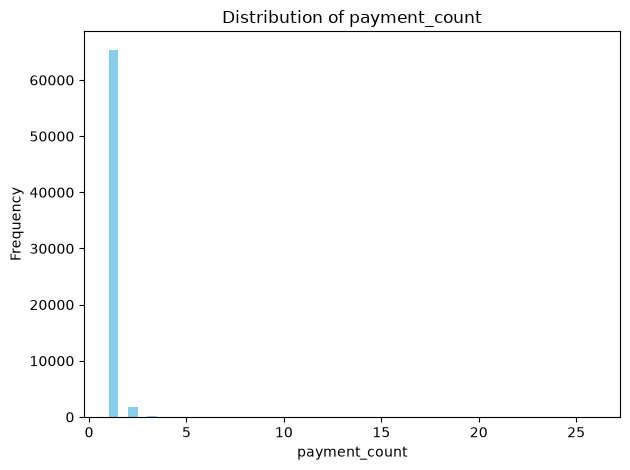

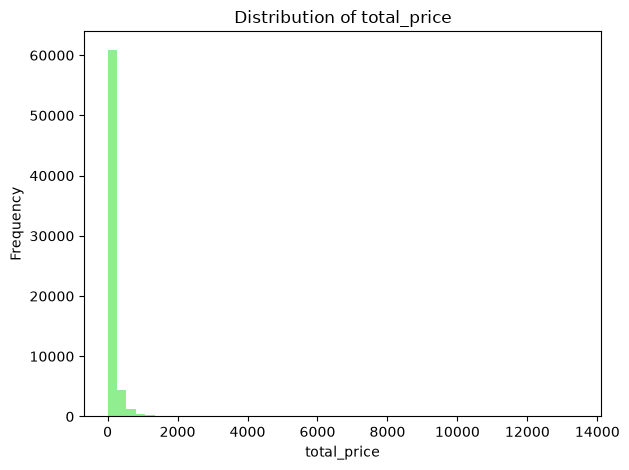

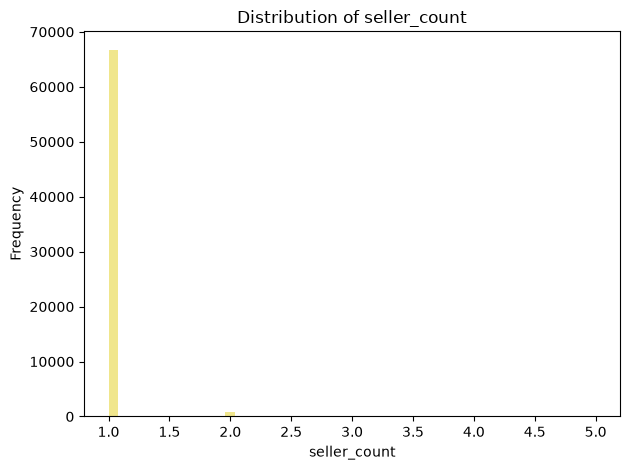

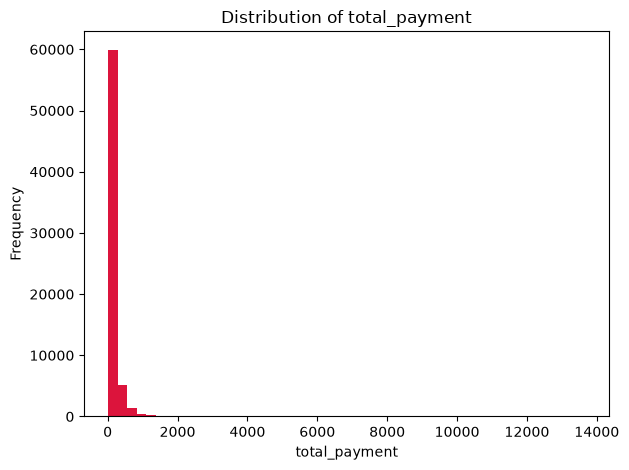

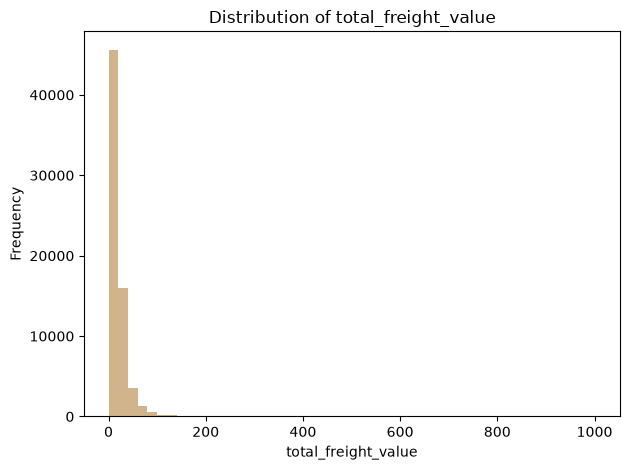

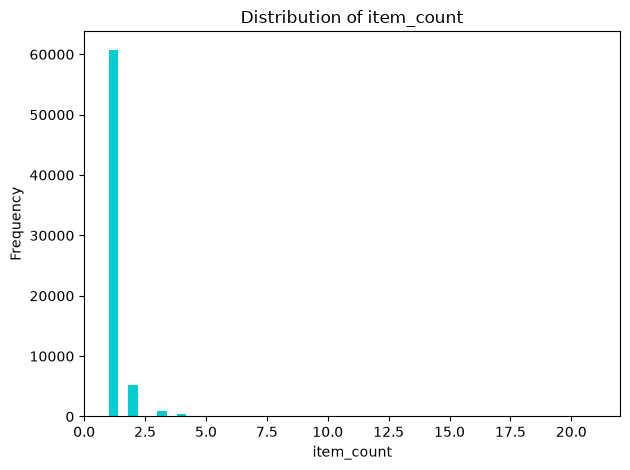

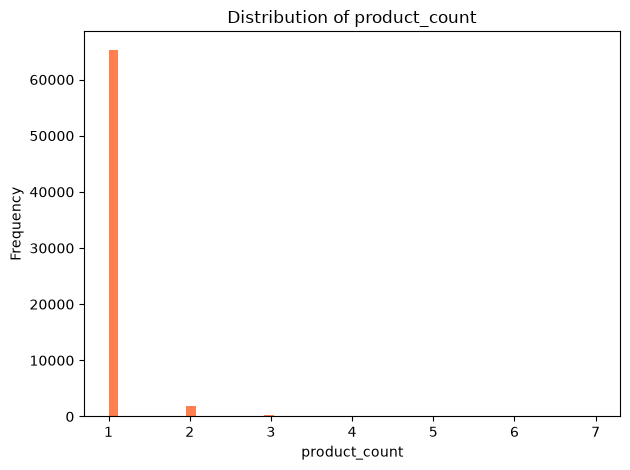

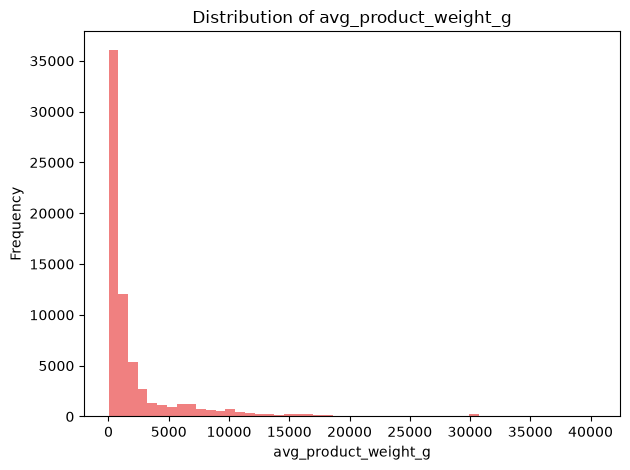

In [120]:
features = ['payment_count',
'total_price',
'seller_count',
'total_payment',
'total_freight_value',
'item_count',
'product_count',
'avg_product_weight_g']

colors = ['skyblue', 'lightgreen', 'khaki', 'crimson', 'tan', 'darkturquoise', 'coral', 'lightcoral']

for num, col in enumerate(features):
    plt.hist(data[col].dropna(), bins = 50, color = colors[num])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()




#### Checking the outliers

In [122]:
# Checking the outlier by using the IQR

outliers_summary = []

for col in numerical_columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((data[col] < lower) | (data[col] > upper)).sum()

    outliers_summary.append({
        'feature': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outliers,
        'outlier_prc': outliers / len(data) * 100
    })

outliers_summary = pd.DataFrame(outliers_summary)

outliers_summary

,feature,lower_bound,upper_bound,outlier_count,outlier_prc
0,item_count,1.000000,1.000000,6759,10.008440
1,total_price,-110.099987,305.899982,5361,7.938341
2,total_freight_value,-0.300000,38.100001,6621,9.804096
3,payment_count,1.000000,1.000000,2129,3.152533
4,total_payment,-109.152493,346.267490,5308,7.859861
5,avg_product_name_length,19.500000,79.500000,435,0.644130
6,avg_product_description_length,-606.000000,1922.000000,4022,5.955607
7,avg_product_height_cm,-10.000000,38.000000,4915,7.277923
8,avg_product_length_cm,-13.500000,70.500000,1853,2.743844
9,avg_product_photos_qty,-2.000000,6.000000,1931,2.859343


In [123]:
outliers_summary.sort_values('outlier_prc', ascending = False)

,feature,lower_bound,upper_bound,outlier_count,outlier_prc
11,avg_product_weight_g,-2025.000000,4175.000000,9768,14.464040
0,item_count,1.000000,1.000000,6759,10.008440
2,total_freight_value,-0.300000,38.100001,6621,9.804096
14,late,0.000000,0.000000,6097,9.028179
1,total_price,-110.099987,305.899982,5361,7.938341
4,total_payment,-109.152493,346.267490,5308,7.859861
7,avg_product_height_cm,-10.000000,38.000000,4915,7.277923
6,avg_product_description_length,-606.000000,1922.000000,4022,5.955607
12,product_count,1.000000,1.000000,2210,3.272474
3,payment_count,1.000000,1.000000,2129,3.152533


#### Numerical Features vs late

In [126]:
data[numerical_columns].groupby(data['late']).mean().T

late,0,1
item_count,1.144834,1.114319
total_price,134.506742,149.767376
total_freight_value,21.950632,25.202941
payment_count,1.048359,1.040190
total_payment,156.496706,175.007633
avg_product_name_length,48.697977,49.053986
avg_product_description_length,778.179958,774.735417
avg_product_height_cm,16.638473,17.336887
avg_product_length_cm,30.498877,31.650812
avg_product_photos_qty,2.244843,2.201905


In [130]:
data.groupby('late')[numerical_columns].median().T

late,0,1
item_count,1.000000,1.000000
total_price,84.989998,89.989998
total_freight_value,16.600000,18.120001
payment_count,1.000000,1.000000
total_payment,103.050003,113.855000
avg_product_name_length,52.000000,52.000000
avg_product_description_length,593.000000,586.000000
avg_product_height_cm,13.000000,13.000000
avg_product_length_cm,25.000000,25.000000
avg_product_photos_qty,2.000000,1.000000


#### Categorical

In [133]:
(data.select_dtypes(include = 'str').columns).tolist()

['order_id',
 'customer_id',
 'order_status',
 'customer_unique_id',
 'customer_city',
 'customer_state']

In [134]:
categorical_columns = ['order_id',
 'customer_id',
 'order_status',
 'customer_unique_id',
 'customer_city',
 'customer_state']

for col in categorical_columns:
    print(f'----------- {col} -----------')
    print(f'Unique: {data[col].nunique()}')
    print(data[col].value_counts().head(10))


----------- order_id -----------
Unique: 67533
order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
00048cc3ae777c65dbb7d2a0634bc1ea    1
00054e8431b9d7675808bcb819fb4a32    1
0005a1a1728c9d785b8e2b08b904576c    1
00061f2a7bc09da83e415a52dc8a4af1    1
0008288aa423d2a3f00fcb17cd7d8719    1
000c3e6612759851cc3cbb4b83257986    1
Name: count, dtype: int64
----------- customer_id -----------
Unique: 67533
customer_id
3ce436f183e68e07877b285a838db11a    1
f6dd3ec061db4e3987629fe6b26e5cce    1
6489ae5e4333f3693df5ad4372dab6d3    1
58dbd0b2d70206bf40e62cd34e84d795    1
816cbea969fe5b689b39cfc97a506742    1
32e2e6ab09e778d99bf2e0ecd4898718    1
16150771dfd4776261284213b89c304e    1
c6fc061d86fab1e2b2eac259bac71a49    1
2355af7c75e7c98b43a87b2a7f210dc5    1
3773bcf1a6fbd29233ea1c1b573c4f22    1
Name: count, dtype: int64
----------- order_status -----------
Unique: 2
order_status
delivered 

In [ ]:
for col in categorical_columns:
    print(f'----------- {col} vs late -----------')
    print(data.groupby(col)['late'].agg(['count', 'mean']).sort_values('count', ascending = False).head(10))


----------- order_id vs late -----------
                                  count  mean
order_id                                     
00010242fe8c5a6d1ba2dd792cb16214      1   0.0
00018f77f2f0320c557190d7a144bdd3      1   0.0
000229ec398224ef6ca0657da4fc703e      1   0.0
00042b26cf59d7ce69dfabb4e55b4fd9      1   0.0
00048cc3ae777c65dbb7d2a0634bc1ea      1   0.0
00054e8431b9d7675808bcb819fb4a32      1   0.0
0005a1a1728c9d785b8e2b08b904576c      1   1.0
00061f2a7bc09da83e415a52dc8a4af1      1   0.0
0008288aa423d2a3f00fcb17cd7d8719      1   0.0
000c3e6612759851cc3cbb4b83257986      1   0.0
----------- customer_id vs late -----------
                                  count  mean
customer_id                                  
00012a2ce6f8dcda20d059ce98491703      1   0.0
000161a058600d5901f007fab4c27140      1   0.0
0001fd6190edaaf884bcaf3d49edf079      1   0.0
0002414f95344307404f0ace7a26f1d5      1   0.0
000379cdec625522490c315e70c7a9fb      1   0.0
0004164d20a9e969af783496f3408652      1  

#### Correlation

In [148]:
corr = data[numerical_columns].corrwith(data['late']).sort_values(ascending = False)

corr

late                              1.000000
total_freight_value               0.046604
avg_product_weight_g              0.025671
total_payment                     0.024756
total_price                       0.021315
avg_product_length_cm             0.020179
avg_product_height_cm             0.014716
avg_product_name_length           0.010210
avg_product_width_cm              0.009660
avg_product_description_length   -0.001513
payment_count                    -0.005894
avg_product_photos_qty           -0.007057
item_count                       -0.016146
product_count                    -0.021611
seller_count                     -0.025872
dtype: float64

#### Dates

In [150]:
data['delivery_days'] = (
    data['order_delivered_customer_date']
    - data['order_purchase_timestamp']).dt.total_seconds() / (24 * 60 * 60)


In [151]:
data.groupby('late')['delivery_days'].describe()

,count,mean,std,min,25%,50%,75%,max
late,,,,,,,,
0,61436.0,11.772115,6.346435,0.533414,7.145868,10.801806,15.193866,70.213611
1,6097.0,34.508173,16.955728,7.772269,25.028310,31.271493,39.906852,209.628611


In [152]:
data['purchase_dayofweek'] = (
    data['order_purchase_timestamp'].dt.dayofweek
)

data.groupby('purchase_dayofweek')['late'].mean()

purchase_dayofweek
0    0.100224
1    0.092646
2    0.086082
3    0.082859
4    0.094689
5    0.089676
6    0.083808
Name: late, dtype: float64

In [155]:
data['purchase_month'] = (
    data['order_purchase_timestamp'].dt.month
)

In [156]:
data.loc[:, ['delivery_days', 'purchase_dayofweek', 'purchase_month', 'late']].head(10)

,delivery_days,purchase_dayofweek,purchase_month,late
0,7.614421,2,9,0
1,16.216181,2,4,0
2,7.948437,6,1,0
4,25.114352,5,2,0
5,6.668067,0,5,0
6,8.423495,6,12,0
8,9.984005,0,3,1
10,4.075104,5,3,0
13,12.656262,1,2,0
17,7.217593,5,8,0


#### Geography

In [157]:
state_late = (
    data.groupby('customer_state')['late']
    .agg(['count', 'mean'])
    .sort_values('mean', ascending=False)
)

state_late

,count,mean
customer_state,,
AL,298,0.278523
MA,548,0.215328
CE,948,0.182489
RR,29,0.172414
SE,246,0.170732
PI,348,0.166667
RJ,8967,0.165830
BA,2307,0.149978
PA,718,0.133705


#### Finding Summary

In [160]:
findings = """EDA Findings:
1. The target is imbalanced, with late orders representing approximately 9% of the training data.
2. Several numerical variables are strongly right-skewed, especially payment_count, total_price, total_payment, and freight value.
3. High-value observations exist and should not automatically be removed because they may represent genuine orders.
4. Product-related variables contain missing values, likely due to missing product information.
5. item_count, product_count, seller_count, and payment_count are concentrated around 1 but have long right tails.
6. Categorical variables such as customer_state have different cardinalities and should be encoded appropriately.
7. Delivery-related dates are useful for analysis and label validation, but post-delivery information must not be used as model features because of data leakage.
8. Purchase date features may provide useful predictive information and can be transformed into calendar-based features."""

print(findings)

EDA Findings:
1. The target is imbalanced, with late orders representing approximately 9% of the training data.
2. Several numerical variables are strongly right-skewed, especially payment_count, total_price, total_payment, and freight value.
3. High-value observations exist and should not automatically be removed because they may represent genuine orders.
4. Product-related variables contain missing values, likely due to missing product information.
5. item_count, product_count, seller_count, and payment_count are concentrated around 1 but have long right tails.
6. Categorical variables such as customer_state have different cardinalities and should be encoded appropriately.
7. Delivery-related dates are useful for analysis and label validation, but post-delivery information must not be used as model features because of data leakage.
8. Purchase date features may provide useful predictive information and can be transformed into calendar-based features.
